<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/pipeline_airbnb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline as Skpipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Airbnb_Open_Data.csv',low_memory=False)

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.shape

(102599, 26)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,102599.0,2.914623e+07,1.625751e+07,1.001254e+06,1.508581e+07,2.913660e+07,4.320120e+07,5.736742e+07
host id,102599.0,4.925411e+10,2.853900e+10,1.236005e+08,2.458333e+10,4.911774e+10,7.399650e+10,9.876313e+10
lat,102591.0,4.072809e+01,5.585652e-02,4.049979e+01,4.068874e+01,4.072229e+01,4.076276e+01,4.091697e+01
long,102591.0,-7.394964e+01,4.952126e-02,-7.424984e+01,-7.398258e+01,-7.395444e+01,-7.393235e+01,-7.370522e+01
Construction year,102385.0,2.012487e+03,5.765556e+00,2.003000e+03,2.007000e+03,2.012000e+03,2.017000e+03,2.022000e+03
minimum nights,102190.0,8.135845e+00,3.055378e+01,-1.223000e+03,2.000000e+00,3.000000e+00,5.000000e+00,5.645000e+03
number of reviews,102416.0,2.748374e+01,4.950895e+01,0.000000e+00,1.000000e+00,7.000000e+00,3.000000e+01,1.024000e+03
reviews per month,86720.0,1.374022e+00,1.746621e+00,1.000000e-02,2.200000e-01,7.400000e-01,2.000000e+00,9.000000e+01
review rate number,102273.0,3.279106e+00,1.284657e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
calculated host listings count,102280.0,7.936605e+00,3.221878e+01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.320000e+02


In [6]:
df.select_dtypes('number').nunique()

,0
id,102058
host id,102057
lat,21991
long,17774
Construction year,20
minimum nights,153
number of reviews,476
reviews per month,1016
review rate number,5
calculated host listings count,78


In [7]:
df.drop(['id','host id','NAME','host name','country','country code','license','house_rules'],axis=1,inplace=True)

In [8]:
df['price']

,price
0,$966
1,$142
2,$620
3,$368
4,$204
...,...
102594,$844
102595,$837
102596,$988
102597,$546


In [9]:
df['price']=df['price'].str.replace('$','')
df['price']=df['price'].str.replace(',','').astype('float64')
df['service fee']=df['service fee'].str.replace('$','')
df['service fee']=df['service fee'].str.replace(',','').astype('float64')

In [10]:
df.select_dtypes('object').nunique()

,0
host_identity_verified,2
neighbourhood group,7
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4
last review,2477


In [11]:
df['last review']=pd.to_datetime(df['last review'])

In [12]:
df['Year']=df['last review'].dt.year

In [13]:
df['Building Age']=df['Year']-df['Construction year']

In [14]:
df.drop(['Year','last review'],axis=1,inplace=True)

In [15]:
df.select_dtypes('object').nunique()

,0
host_identity_verified,2
neighbourhood group,7
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4


In [16]:
df['neighbourhood group'].value_counts()

,count
neighbourhood group,
Manhattan,43792
Brooklyn,41842
Queens,13267
Bronx,2712
Staten Island,955
brookln,1
manhatan,1


In [17]:
df['neighbourhood group']=df['neighbourhood group'].str.replace('manhatan','Manhattan')
df['neighbourhood group']=df['neighbourhood group'].str.replace('brookln','Brooklyn')

In [18]:
df.select_dtypes('object').nunique()

,0
host_identity_verified,2
neighbourhood group,5
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4


In [19]:
df.duplicated().sum()

np.int64(3636)

In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['price'].isna().sum()

np.int64(247)

In [23]:
df=df[df['price'].notna()]

In [24]:
df['price'].isna().sum()

np.int64(0)

In [25]:
df.shape

(98716, 18)

In [26]:
df.isna().sum()

,0
host_identity_verified,285
neighbourhood group,28
neighbourhood,15
lat,8
long,8
instant_bookable,100
cancellation_policy,71
room type,0
Construction year,210
price,0


In [27]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
service fee,0.999991
number of reviews,0.004896
Building Age,0.004302
reviews per month,0.004164
long,0.002835
calculated host listings count,0.000621
availability 365,-0.001918
minimum nights,-0.003093
Construction year,-0.003807


In [28]:
(df['service fee']/df['price']).describe()

,0
count,98477.000000
mean,0.199993
std,0.001151
min,0.192308
25%,0.199609
50%,0.200000
75%,0.200389
max,0.207547


In [29]:
df.drop(['service fee'],axis=1,inplace=True)
df.shape

(98716, 17)

In [30]:
df['price_per_night'] = df['price'] / df['minimum nights']
df['review_activity'] = df['reviews per month'] * df['number of reviews']
df['booking_intensity'] = df['availability 365'] / df['minimum nights']
df['is_verified_host'] = (df['host_identity_verified'] == 'verified').astype(int)
df['has_review_rate'] = df['review rate number'].notna().astype(int)

In [31]:
df['price_log']=np.log1p(df['price'])

In [32]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(['price','price_log'],axis=1),df['price_log'],test_size=0.2,random_state=1)

In [33]:
X_train.shape

(78972, 21)

In [34]:
X_test.shape

(19744, 21)

In [35]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,78965.0,40.728034,0.055848,40.50641,40.68866,40.72216,40.76268,40.916970
long,78965.0,-73.949591,0.049581,-74.24442,-73.98262,-73.95445,-73.93240,-73.705220
Construction year,78799.0,2012.492316,5.767713,2003.00000,2008.00000,2012.00000,2018.00000,2022.000000
minimum nights,78660.0,8.112599,30.075457,-1223.00000,2.00000,3.00000,5.00000,5645.000000
number of reviews,78821.0,27.623057,49.703004,0.00000,1.00000,7.00000,31.00000,1010.000000
reviews per month,66679.0,1.378674,1.736776,0.01000,0.22000,0.75000,2.01000,90.000000
review rate number,78722.0,3.283555,1.283380,1.00000,2.00000,3.00000,4.00000,5.000000
calculated host listings count,78738.0,7.986804,32.321996,1.00000,1.00000,1.00000,2.00000,332.000000
availability 365,78597.0,142.189231,135.645236,-10.00000,4.00000,98.00000,270.00000,3677.000000
Building Age,66516.0,6.521905,6.000638,-9.00000,2.00000,7.00000,11.00000,50.000000


In [36]:
num_col=X_train.select_dtypes('number').columns.tolist()
cat_col=X_train.select_dtypes('object').columns.tolist()

X_train_imputed=X_train.copy()
X_test_imputed=X_test.copy()

X_train_imputed[num_col]=SimpleImputer(strategy='median').fit_transform(X_train[num_col])
X_test_imputed[num_col]=SimpleImputer(strategy='median').fit(X_train[num_col]).transform(X_test[num_col])

X_train_imputed[cat_col]=SimpleImputer(strategy='most_frequent').fit_transform(X_train[cat_col])
X_test_imputed[cat_col]=SimpleImputer(strategy='most_frequent').fit(X_train[cat_col]).transform(X_test[cat_col])

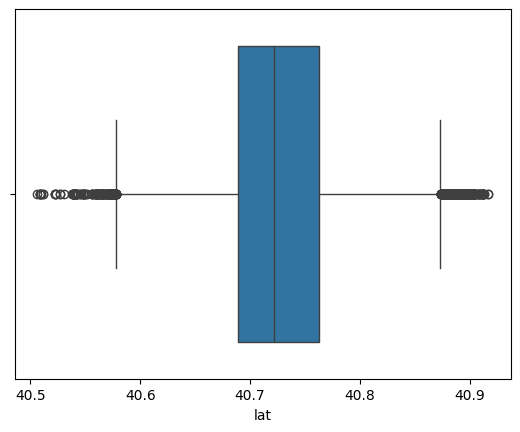

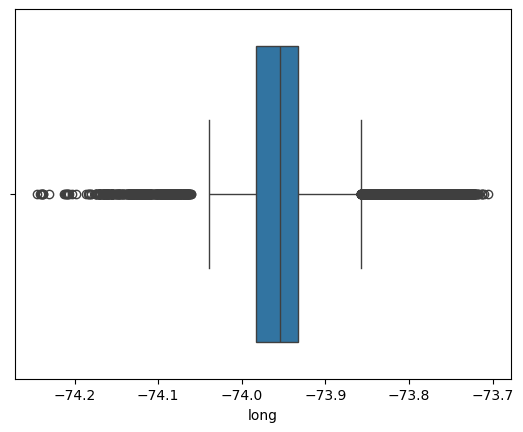

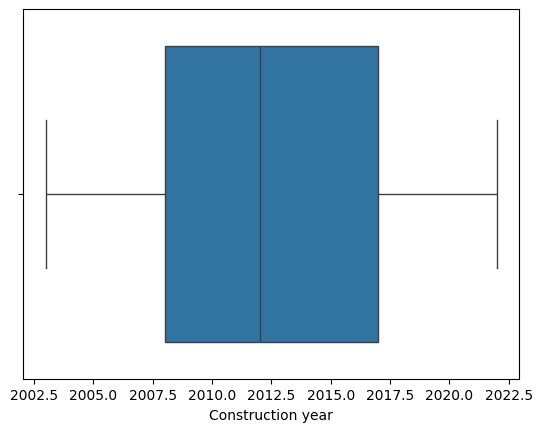

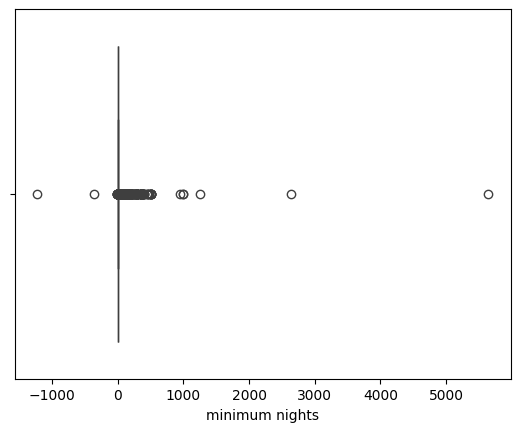

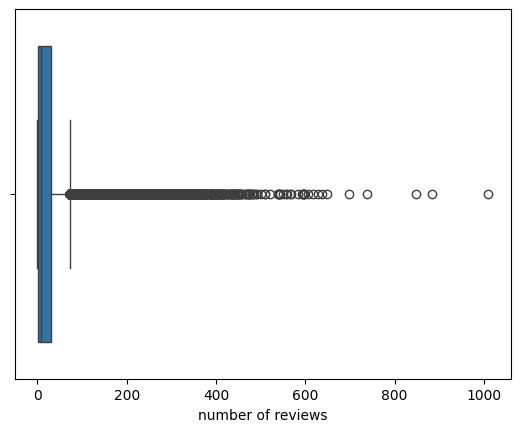

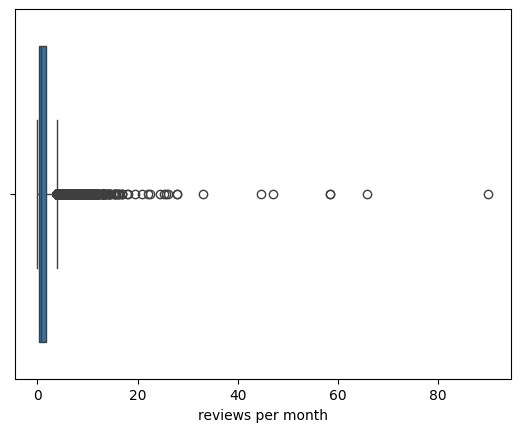

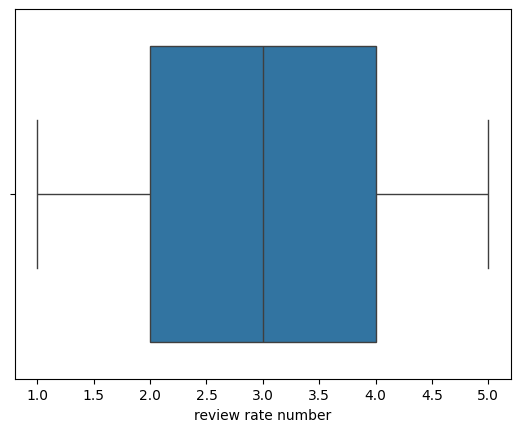

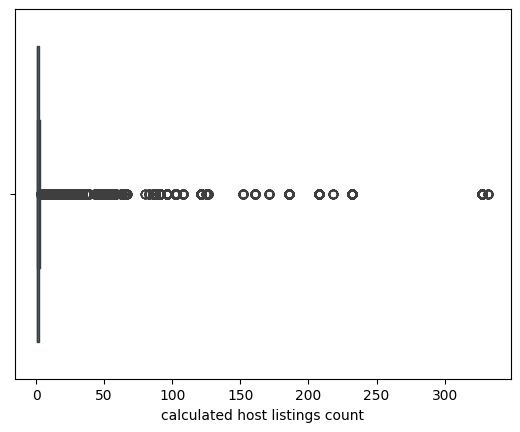

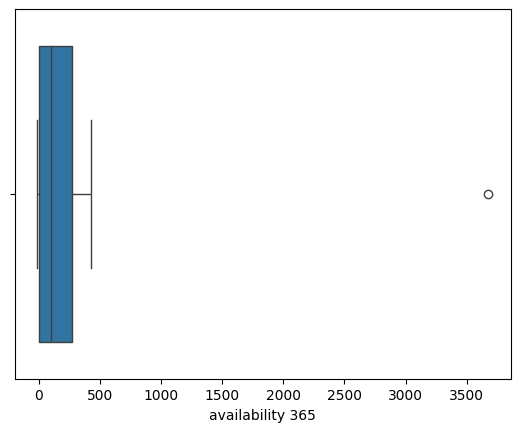

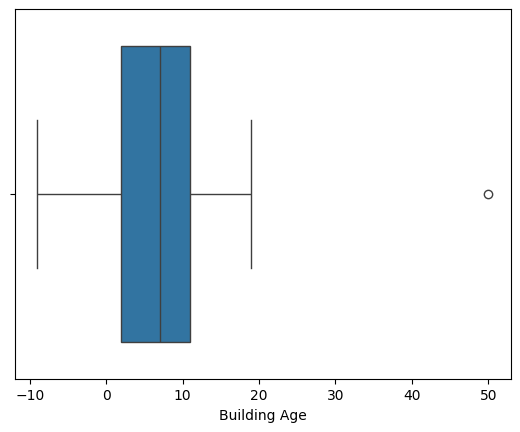

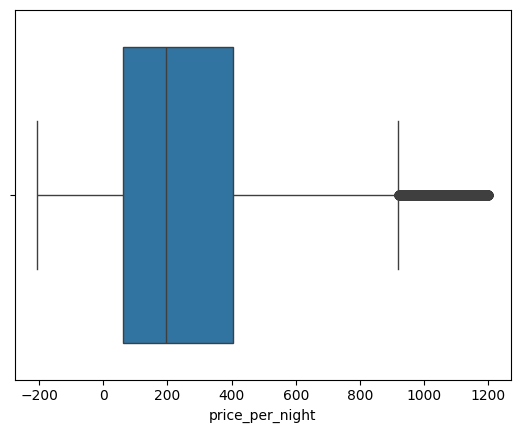

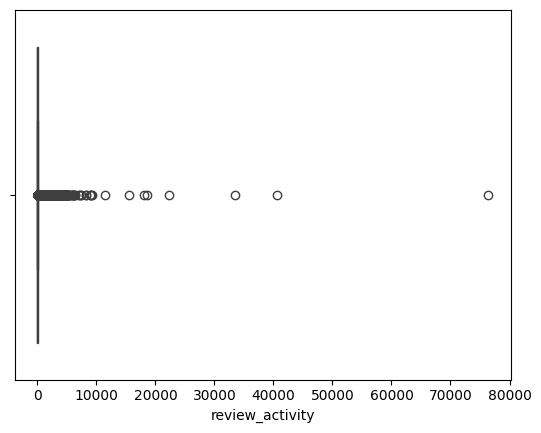

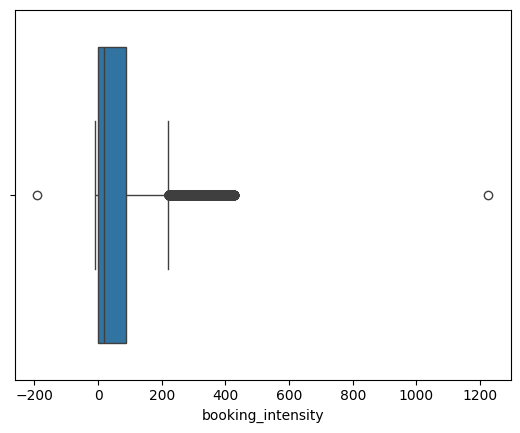

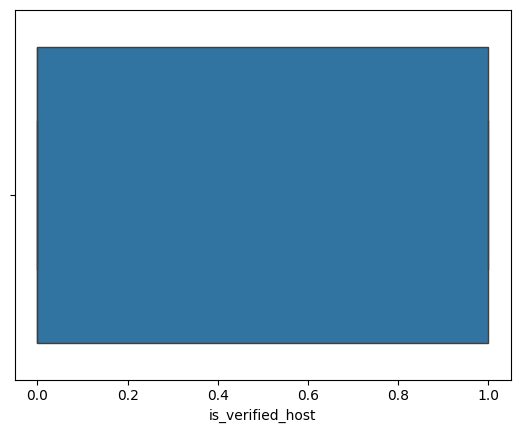

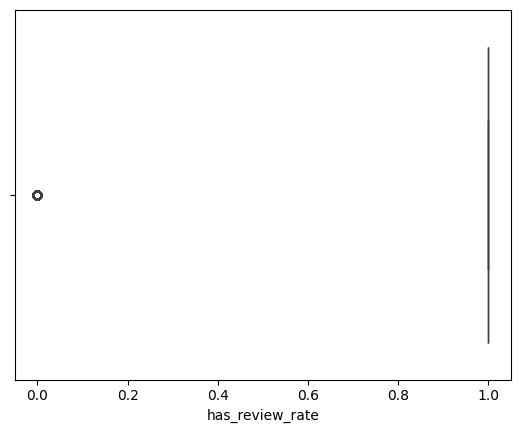

In [37]:
for i in num_col:
  sns.boxplot(x=X_train_imputed[i])
  plt.show()

In [38]:
# minimum nights, number of reviews, reviews per month, calculated host listings count, availability 365, building age

In [39]:
X_train_imputed.columns.to_list()

['host_identity_verified',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'minimum nights',
 'number of reviews',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'Building Age',
 'price_per_night',
 'review_activity',
 'booking_intensity',
 'is_verified_host',
 'has_review_rate']

In [40]:
z=['minimum nights',
 'number of reviews',
 'reviews per month',
 'calculated host listings count',
 'availability 365',
 'price_per_night',
 'review_activity',
 'booking_intensity']

for i in [X_train_imputed,X_test_imputed]:
  for j in z:
    i[j]=i[j].clip(lower=0)
    i[j+'_log']=np.log1p(i[j])

X_train_imputed.drop(columns=z,inplace=True)
X_test_imputed.drop(columns=z,inplace=True)

    handle_unknown='ignore',sparse_output=False  ye dono smjh nhi aaye kya h

In [41]:
num_col=X_train_imputed.select_dtypes('number').columns.tolist()
cat_col=X_train_imputed.select_dtypes('object').columns.tolist()

num_pipeline=Skpipeline([('MinMaxScaler',MinMaxScaler())])
cat_pipeline=Skpipeline([('encoder',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))])
preprocessor=ColumnTransformer([('num',num_pipeline,num_col),('cat',cat_pipeline,cat_col)],remainder='passthrough')

In [42]:
pipe=Skpipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())])

In [43]:
pipe.fit(X_train_imputed,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('MinMaxScaler',
                                                                   MinMaxScaler())]),
                                                  ['lat', 'long',
                                                   'Construction year',
                                                   'review rate number',
                                                   'Building Age',
                                                   'is_verified_host',
                                                   'has_review_rate',
                                                   'minimum nights_log',
                                                   'number of reviews_log',
                                                   'reviews per month_log',
                                                   'calculated host listings '
                                                   'count_log',
                                                   'availability 365_log',
                                                   'price_per_night_log',
                                                   'review_activity_log',
                                                   'booking_intensity_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['host_identity_verified',
                                                   'neighbourhood group',
                                                   'neighbourhood',
                                                   'instant_bookable',
                                                   'cancellation_policy',
                                                   'room type'])])),
                ('model', LinearRegression())])

In [44]:
y_pred_train=pipe.predict(X_train_imputed)
y_pred_test=pipe.predict(X_test_imputed)

In [45]:
r2_score(y_test,y_pred_test)

0.9479295352831363

In [46]:
r2_score(y_train,y_pred_train)

0.9571962472657068